# Familiar Faces: Integrative Industry Synthesis

## A Human-Supervised AI Prototype for Community Paramedicine Outreach

This notebook demonstrates an integrated statistical, machine-learning, fairness-governance, and controlled-drafting workflow for a proposed **Familiar Faces** community paramedicine program.

The system uses only synthetic EHR-like records. It is an educational prototype and is not approved for clinical care, operational deployment, autonomous eligibility decisions, or autonomous patient contact.

## Safety and Governance Boundaries

The prototype enforces the following boundaries:

- Synthetic data only
- No protected demographic fields used as model predictors
- No demographics included in generated case materials
- No diagnosis or treatment recommendations
- No autonomous eligibility decisions
- No autonomous patient contact
- Human review required for every model flag and drafted outreach plan
- Fairness differences trigger governance review rather than automatic approval or rejection

In [1]:
import pandas as pd
from IPython.display import Image, display

from familiar_faces_system import (
    MODEL_FEATURES,
    SYSTEM_BOUNDARIES,
    run_integrated_system,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Notebook environment initialized.")
print("Model features:", len(MODEL_FEATURES))
print("Human review required:", SYSTEM_BOUNDARIES["human_review_required"])
print("Autonomous contact allowed:", SYSTEM_BOUNDARIES["autonomous_contact_allowed"])

Notebook environment initialized.
Model features: 16
Human review required: True
Autonomous contact allowed: False


## Integrated System Architecture

The workflow contains five connected layers:

1. **Synthetic data and schema validation**
2. **Descriptive statistical analysis**
3. **Machine-learning model comparison and prioritization**
4. **Protected-group fairness auditing and governance assessment**
5. **Deterministic, constrained drafting for human review**

The machine-learning output is an advisory prioritization signal. It does not determine program eligibility or initiate outreach.

In [2]:
outputs = run_integrated_system()

print("End-to-end pipeline executed successfully.")
print("Deployment status: EDUCATIONAL SYNTHETIC-DATA PROTOTYPE")

End-to-end pipeline executed successfully.
Deployment status: EDUCATIONAL SYNTHETIC-DATA PROTOTYPE


## 1. Synthetic Data Validation

The dataset represents simulated community-paramedicine records. Synthetic identifiers and the explicit `data_source` field help prevent the prototype from being mistaken for a real clinical system.

In [3]:
data = outputs["data"]

validation_summary = pd.DataFrame(
    {
        "validation_item": [
            "records",
            "columns",
            "unique_patient_identifiers",
            "missing_values",
            "data_sources",
        ],
        "result": [
            len(data),
            len(data.columns),
            data["synthetic_patient_id"].nunique(),
            int(data.isna().sum().sum()),
            ", ".join(sorted(data["data_source"].unique())),
        ],
    }
)

display(validation_summary)

,validation_item,result
0,records,3000
1,columns,22
2,unique_patient_identifiers,3000
3,missing_values,0
4,data_sources,synthetic


## 2. Statistical Analysis

Descriptive analysis examines utilization, social-support needs, primary-care connection, and the simulated outreach-response outcome. These associations describe the synthetic dataset and do not establish causal relationships.

,metric,value
0,synthetic_records,3000.000000
1,outreach_response_rate,0.389667
2,mean_ems_calls_12m,2.502000
3,median_ems_calls_12m,2.000000
4,frequent_utilizer_rate_4plus,0.257333
5,frequent_utilizer_response_rate,0.562176
6,high_social_need_rate_3plus,0.281667
7,high_social_need_response_rate,0.550296
8,primary_care_connected_rate,0.707667


,utilization_band,synthetic_records,mean_social_needs,outreach_response_rate
0,0,347,0.893372,0.236311
1,1-3,1881,1.553961,0.347156
2,4-6,670,2.561194,0.537313
3,7+,102,3.549020,0.725490


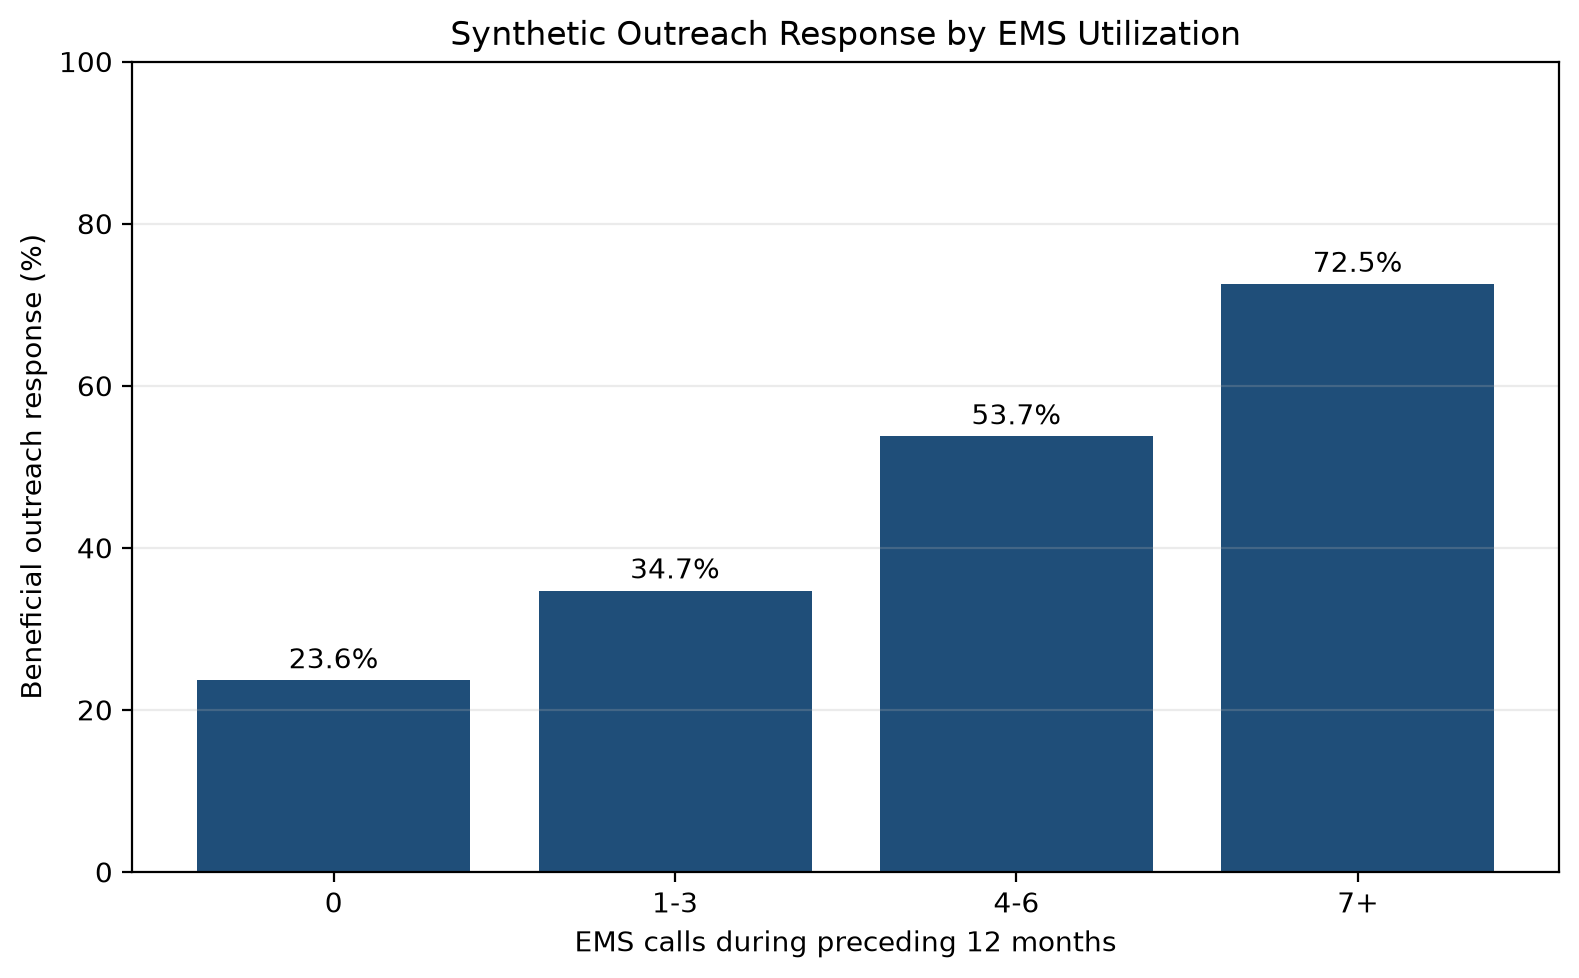

In [4]:
display(outputs["statistical_summary"])
display(outputs["utilization_results"])

display(
    Image(
        filename="figures/outreach_response_by_utilization.png",
        width=750,
    )
)

## 3. Machine-Learning Comparison

Logistic regression and random forest models are compared on the same stratified test set. Selection is based on ROC AUC, while average precision and classification metrics provide additional context.

The moderate model performance supports limited use as a human-reviewed prioritization aid—not as an autonomous decision system.

Selected model: logistic_regression


,model,test_records,roc_auc,average_precision,accuracy,precision,recall,f1,positive_prediction_rate
0,logistic_regression,750,0.685208,0.579084,0.646667,0.543974,0.571918,0.557596,0.409333
1,random_forest,750,0.678277,0.572430,0.640000,0.541045,0.496575,0.517857,0.357333


,feature,importance
0,ems_calls_12m,0.311700
1,prior_outreach_engaged,0.217870
2,medication_access_barrier,0.206882
3,primary_care_connected,0.165087
4,social_need_count,0.156127
5,transportation_barrier,0.136138
6,chronic_condition_count,0.106805
7,food_insecurity,0.092865
8,hospital_admissions_12m,0.077221
9,ed_visits_12m,0.053361


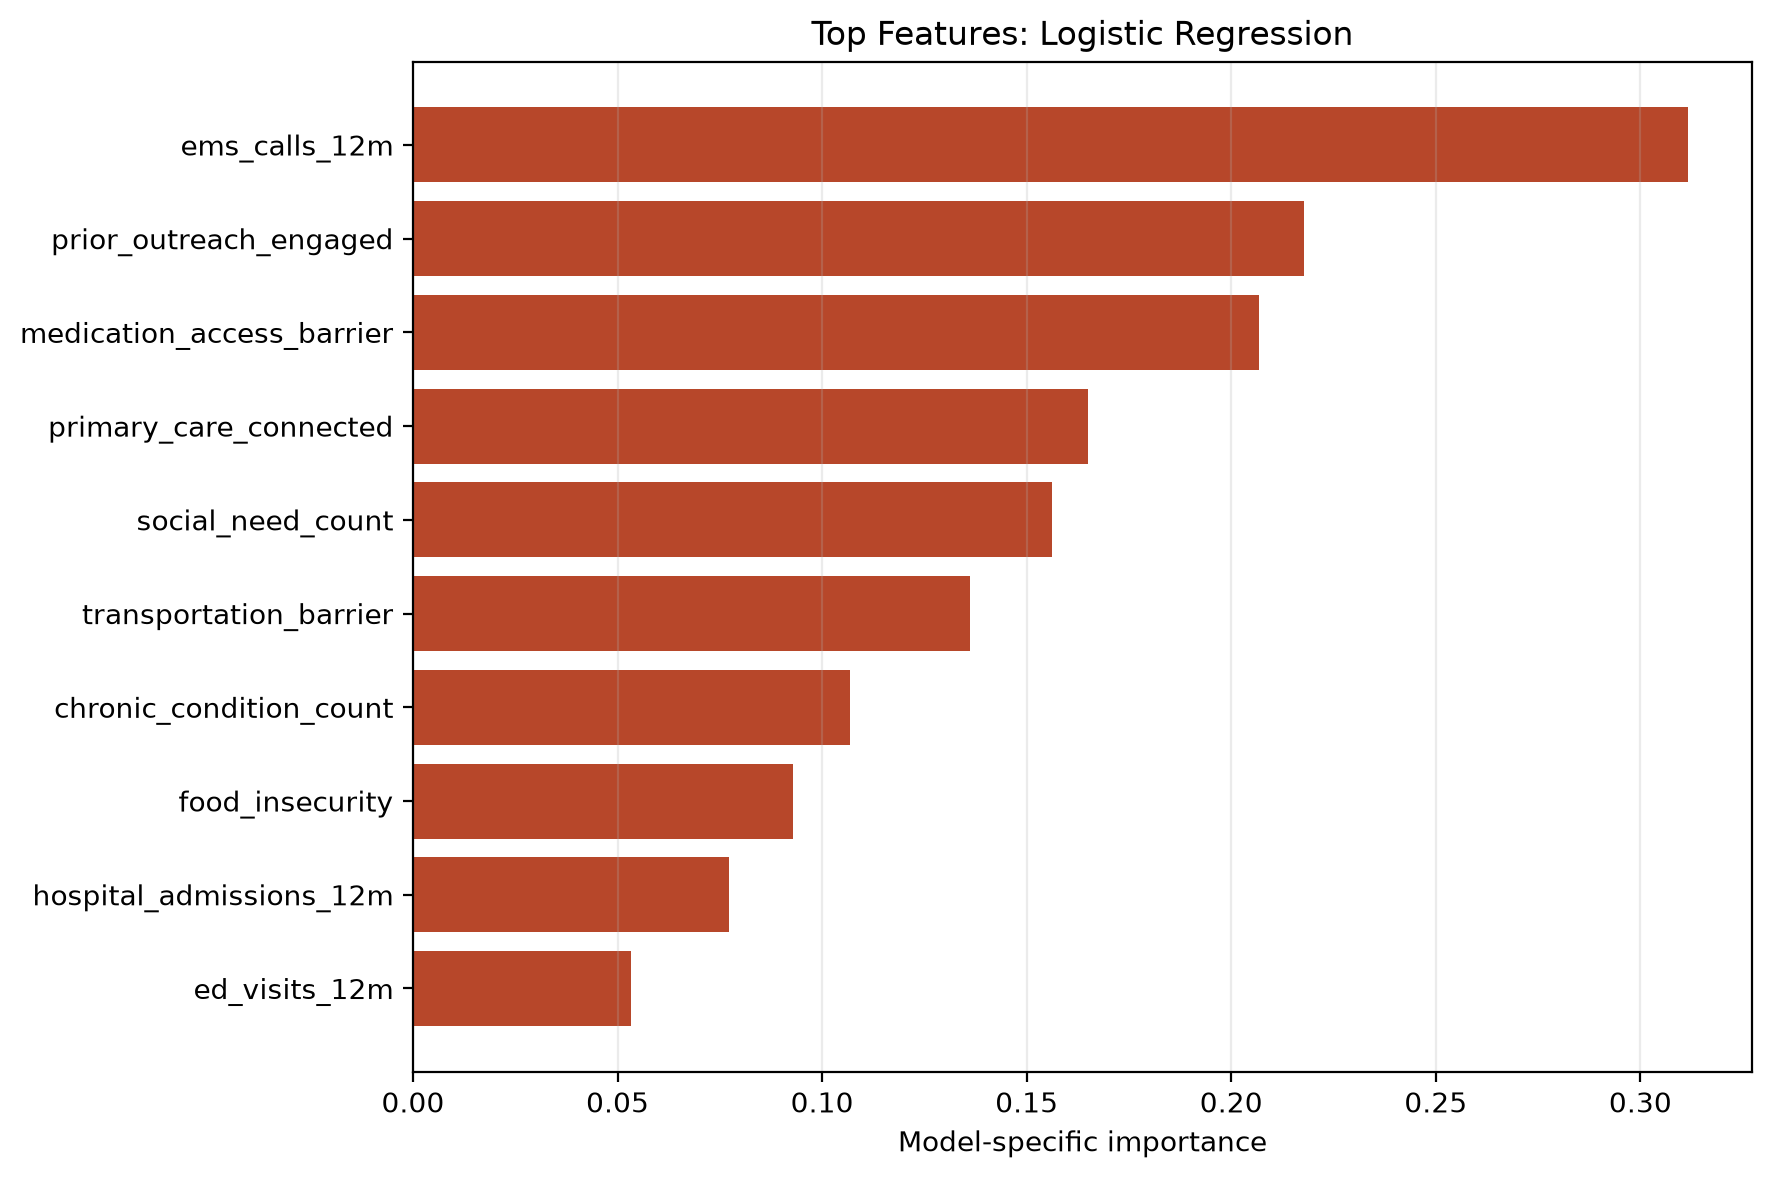

In [5]:
print("Selected model:", outputs["selected_model_name"])
display(outputs["model_comparison"])
display(outputs["feature_importance"].head(10))

display(
    Image(
        filename="figures/selected_model_feature_importance.png",
        width=800,
    )
)

## 4. Fairness Audit and Governance Review

Age group, sex, and race/ethnicity are excluded from model training but retained for post-model auditing. Groups with fewer than 25 test records are excluded from disparity-range calculations.

The internal 0.10 difference threshold is a monitoring trigger. It is not a legal definition of fairness or a deployment-certification standard.

In [6]:
display(outputs["fairness_assessment"])

print("Groups excluded from disparity ranges because of small samples:")
display(outputs["excluded_groups"])

print("Overall fairness governance status:", outputs["fairness_status"])

,audit_field,metric,eligible_groups,minimum_group_rate,maximum_group_rate,max_minus_min_difference,monitoring_threshold,governance_action
0,age_group,human_review_flag_rate,5,0.323232,0.442748,0.119516,0.1,REVIEW_REQUIRED
1,age_group,true_positive_rate,5,0.406250,0.619048,0.212798,0.1,REVIEW_REQUIRED
2,age_group,false_positive_rate,5,0.264463,0.342105,0.077642,0.1,MONITOR
3,sex,human_review_flag_rate,2,0.356742,0.463158,0.106416,0.1,REVIEW_REQUIRED
4,sex,true_positive_rate,2,0.533333,0.618421,0.085088,0.1,MONITOR
5,sex,false_positive_rate,2,0.248869,0.359649,0.110780,0.1,REVIEW_REQUIRED
6,race_ethnicity,human_review_flag_rate,5,0.312500,0.432432,0.119932,0.1,REVIEW_REQUIRED
7,race_ethnicity,true_positive_rate,5,0.375000,0.616352,0.241352,0.1,REVIEW_REQUIRED
8,race_ethnicity,false_positive_rate,5,0.076923,0.314516,0.237593,0.1,REVIEW_REQUIRED


Groups excluded from disparity ranges because of small samples:


,audit_field,group,records
5,sex,Another_or_unknown,14
12,race_ethnicity,Native_American,16


Overall fairness governance status: REVIEW_REQUIRED


## 5. Controlled Case-Material Drafting

The prototype creates deterministic, constrained summaries and nonclinical outreach-plan drafts for selected synthetic records.

This component demonstrates how safeguards learned from generative-AI development can be applied without claiming that the current implementation performs live large-language-model inference. Every draft must pass automated checks and then receive human review.

In [7]:
generated = outputs["generated_materials"]

generation_summary = pd.DataFrame(
    {
        "metric": [
            "drafts_generated",
            "drafts_passing_validation",
            "demographics_included",
            "human_review_required_for_all",
        ],
        "value": [
            len(generated),
            int(generated["safety_validation_passed"].sum()),
            bool(generated["demographics_included"].any()),
            bool(generated["human_review_required"].all()),
        ],
    }
)

display(generation_summary)

display(
    generated[
        [
            "synthetic_patient_id",
            "predicted_response_probability",
            "case_summary",
            "draft_outreach_plan",
            "safety_violations",
        ]
    ].head(3)
)

,metric,value
0,drafts_generated,12
1,drafts_passing_validation,12
2,demographics_included,False
3,human_review_required_for_all,True


,synthetic_patient_id,predicted_response_probability,case_summary,draft_outreach_plan,safety_violations
0,FF-00031,0.930460,Synthetic record FF-00031 contains 11 EMS call...,Draft for reviewer consideration: review possi...,NONE
1,FF-01646,0.909875,Synthetic record FF-01646 contains 9 EMS calls...,Draft for reviewer consideration: review possi...,NONE
2,FF-00874,0.904689,Synthetic record FF-00874 contains 8 EMS calls...,Draft for reviewer consideration: review possi...,NONE


## 6. Integrated System Summary

The final summary connects the analytical, predictive, fairness, and controlled-drafting components while preserving the prototype's operational boundaries.

In [8]:
display(outputs["integrated_summary"])

assert outputs["fairness_status"] == "REVIEW_REQUIRED"
assert generated["safety_validation_passed"].all()
assert not generated["demographics_included"].any()
assert SYSTEM_BOUNDARIES["human_review_required"]
assert not SYSTEM_BOUNDARIES["autonomous_contact_allowed"]

print("Integrated notebook validation: PASSED")
print("Human review required: True")
print("Autonomous contact allowed: False")

,system_metric,value
0,synthetic_records,3000
1,data_dictionary_fields,22
2,model_features,16
3,selected_model,logistic_regression
4,test_records,750
5,selected_model_roc_auc,0.685208
6,selected_model_average_precision,0.579084
7,fairness_governance_status,REVIEW_REQUIRED
8,fairness_comparisons_requiring_review,7
9,small_audit_groups_excluded,2


Integrated notebook validation: PASSED
Human review required: True
Autonomous contact allowed: False


## Limitations and Responsible-Use Statement

This prototype has several important limitations:

- All records and outcomes are synthetic.
- The modeled outcome represents simulated outreach response, not clinical benefit.
- Moderate predictive performance limits operational usefulness.
- Observed subgroup disparities require investigation and continued monitoring.
- Small demographic groups produce unstable estimates.
- Feature importance does not establish causality.
- The drafting component is deterministic and constrained rather than live LLM inference.
- The system has not undergone clinical, legal, privacy, cybersecurity, accessibility, or deployment validation.

Before any real-world pilot, the organization would require formal data governance, HIPAA and legal review, community and stakeholder participation, security controls, model validation using appropriately authorized data, workflow testing, consent procedures, audit logging, escalation policies, and ongoing fairness monitoring.